In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.neighbors import KNeighborsClassifier
from hmmlearn import hmm
from tqdm import tqdm
import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('C:/Users/huang/Desktop/ML project/sp500_master_with_clusters.csv')

In [3]:
df.head()

,Date,Close,High,Low,Volume,Log_Return,Rolling_Return_21,Rolling_Volatility_21,KMeans_Label,Rolling_Return_21_scaled,Rolling_Volatility_21_scaled,Spectral_Label,Spectral_Synced,Spectral_Regime_Name,KMeans_Name
0,2000-02-02,1409.119995,1420.609985,1403.489990,1038600000,-0.000114,-0.001533,0.016190,0,-0.769203,0.886530,0,2,Bear Market (High Volatility),Sideways / Correction
1,2000-02-03,1424.969971,1425.780029,1398.520020,1146500000,0.011185,0.000862,0.013915,1,0.273191,0.544806,0,2,Bear Market (High Volatility),"Bull Market (Low Vol, Pos Return)"
2,2000-02-04,1424.369995,1435.910034,1420.630005,1045100000,-0.000421,0.000750,0.013915,1,0.224652,0.544877,0,2,Bear Market (High Volatility),"Bull Market (Low Vol, Pos Return)"
3,2000-02-07,1424.239990,1427.150024,1413.329956,918100000,-0.000091,0.000700,0.013916,1,0.202958,0.545042,0,2,Bear Market (High Volatility),"Bull Market (Low Vol, Pos Return)"
4,2000-02-08,1441.719971,1441.829956,1424.239990,1047700000,0.012198,0.000008,0.012880,1,-0.098277,0.389391,0,2,Bear Market (High Volatility),"Bull Market (Low Vol, Pos Return)"


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').set_index('Date')

In [5]:
print(df.isnull().sum())

Close                           0
High                            0
Low                             0
Volume                          0
Log_Return                      0
Rolling_Return_21               0
Rolling_Volatility_21           0
KMeans_Label                    0
Rolling_Return_21_scaled        0
Rolling_Volatility_21_scaled    0
Spectral_Label                  0
Spectral_Synced                 0
Spectral_Regime_Name            0
KMeans_Name                     0
dtype: int64


In [6]:
# Functions Preparation

# K-means Clustering function
def run_kmeans_clustering(X_scaled, n_clusters=3, random_state=42):
    """
    ENGINE: Runs K-Means Clustering on any given slice of scaled data.
    Designed to be easily called by Member 3 in their rolling window loop.
    
    Parameters:
    - X_scaled: The 2D array of scaled returns and volatility.
    - n_clusters: Number of regimes (default is 3 for Bull, Bear, Sideways).
    - random_state: Ensures reproducibility.
    
    Returns:
    - Array of raw cluster labels.
    """
    kmeans = KMeans(
        n_clusters=n_clusters, 
        n_init=20,                 # Matches the parameter from your notebook
        random_state=random_state
    )
    
    # Fit the model and return the raw labels
    return kmeans.fit_predict(X_scaled)

# Spectral Clustering function
def run_spectral_clustering(X_scaled, n_clusters=3, n_neighbors=35, random_state=42):
    """
    Fits Spectral Clustering on a scaled feature matrix and returns raw integer labels.

    This is the core engine for Track B. It is called by Member 3 inside the
    rolling-window loop on each training window.

    Note: The integer labels returned (0, 1, 2) are ARBITRARY — which number
    gets assigned to "Bull" vs "Bear" can flip between runs or windows.
    Always pass the output through align_regime_labels() before using it.

    Parameters
    ----------
    X_scaled     : np.ndarray, shape (n_days, 2)
                   Scaled feature matrix — [Rolling_Return_21_scaled,
                   Rolling_Volatility_21_scaled] — as produced by Member 1.
    n_clusters   : int, default 3
                   Number of market regimes: Bull, Bear, Sideways.
    n_neighbors  : int, default 20
                   Size of the k-NN neighbourhood graph.
                   Higher = smoother boundaries but slower.
                   20 was chosen after testing on the full 26-year dataset.
    random_state : int, default 42
                   Seed for K-Means step inside spectral embedding (reproducibility).

    Returns
    -------
    np.ndarray of int, shape (n_days,)
        Raw cluster labels in {0, 1, 2}. Label integers are NOT yet meaningful —
        call align_regime_labels() to map them to 0=Sideways, 1=Bull, 2=Bear.
    """
    model = SpectralClustering(
        n_clusters    = n_clusters,
        affinity      = 'nearest_neighbors',  # Sparse k-NN graph — better than dense RBF
        n_neighbors   = n_neighbors,          # Each day connects to its 20 nearest neighbours
        assign_labels = 'kmeans',             # Final assignment via K-Means in spectral space
        random_state  = random_state,
        n_jobs        = -1                    # Use all CPU cores to speed up computation
    )
    return model.fit_predict(X_scaled)

# Label Aligning function


In [7]:
# Different label function forms
# 1.based on return
def align_regime_labels1(df_slice, raw_label_col,
                        vol_col='Rolling_Volatility_21',
                        ret_col='Rolling_Return_21'):
    """
    Resolves the label-flipping problem using a hybrid economic rule.

    Guarantees a stable output convention regardless of which integers
    Spectral Clustering happened to assign in this particular run or window:
        0 = Sideways / Correction
        1 = Bull Market  (Low volatility, positive returns)
        2 = Bear Market  (High volatility, negative/extreme returns)

    Called immediately after run_spectral_clustering() — both in the
    full-sample analysis here and in Member 3's rolling-window HMM loop.

    Parameters
    ----------
    df_slice      : pd.DataFrame
                    The dataframe (or window slice) containing raw labels
                    and the raw feature columns for computing statistics.
    raw_label_col : str
                    Column name holding the raw integer labels from
                    run_spectral_clustering() (or KMeans_Label for Track A).
    vol_col       : str, default 'Rolling_Volatility_21'
                    Column of RAW (unscaled) rolling volatility.
                    Used to identify the Bear regime (highest volatility).
    ret_col       : str, default 'Rolling_Return_21'
                    Column of RAW (unscaled) rolling returns.
                    Used to split Bull vs Sideways among the calm regimes.

    Returns
    -------
    pd.Series of int
        Synced labels aligned to: 0=Sideways, 1=Bull, 2=Bear.
    """
    # Compute mean volatility and mean return for each raw integer label
    stats_vol = df_slice.groupby(raw_label_col)[vol_col].mean()
    stats_ret = df_slice.groupby(raw_label_col)[ret_col].mean()

    # Rule 1: Bear = highest mean volatility (universally true across all windows)
    bear_label = stats_vol.idxmax()

    # Rule 2: Among the remaining two, Bull = higher mean return
    remaining = list(set(stats_vol.index) - {bear_label})
    if stats_ret[remaining[0]] > stats_ret[remaining[1]]:
        bull_label     = remaining[0]
        sideways_label = remaining[1]
    else:
        bull_label     = remaining[1]
        sideways_label = remaining[0]

    # Build dynamic mapping: raw integer → standardised integer
    dynamic_mapping = {
        sideways_label : 0,   # Sideways / Correction
        bull_label     : 1,   # Bull Market
        bear_label     : 2    # Bear Market
    }

    return df_slice[raw_label_col].map(dynamic_mapping)



In [8]:
def align_regime_labels2(df_slice, raw_label_col,
                        vol_col='Rolling_Volatility_21',
                        ret_col='Rolling_Return_21'):
    """
    Resolves the label-flipping problem using a Risk-Adjusted Return rule.
    """
    # Compute mean volatility and mean return for each raw integer label
    stats_vol = df_slice.groupby(raw_label_col)[vol_col].mean()
    stats_ret = df_slice.groupby(raw_label_col)[ret_col].mean()

    # Create a pseudo-Sharpe ratio: Return / Volatility
    risk_adjusted_return = stats_ret / stats_vol

    # Rule 1: Bear = Lowest risk-adjusted return (combines bad returns + high vol)
    bear_label = risk_adjusted_return.idxmin()

    # Rule 2: Bull = Highest risk-adjusted return (combines good returns + low vol)
    bull_label = risk_adjusted_return.idxmax()

    # Rule 3: Sideways = The one left over
    sideways_label = list(set(stats_vol.index) - {bear_label, bull_label})[0]

    # Build dynamic mapping: raw integer → standardised integer
    dynamic_mapping = {
        sideways_label : 0,   # Sideways / Correction
        bull_label     : 1,   # Bull Market
        bear_label     : 2    # Bear Market
    }

    return df_slice[raw_label_col].map(dynamic_mapping)

In [9]:
def align_regime_labels3(df_slice, raw_label_col,
                        vol_col='Rolling_Volatility_21',
                        ret_col='Rolling_Return_21'):
    
    stats_vol = df_slice.groupby(raw_label_col)[vol_col].mean()
    stats_ret = df_slice.groupby(raw_label_col)[ret_col].mean()

    vol_median = stats_vol.median()
    assignments = {}

    for label in stats_vol.index:
        v = stats_vol[label]
        r = stats_ret[label]
        if v >= vol_median and r < 0:
            assignments[label] = 2      # 高波动+负收益 → 熊市
        elif v < vol_median and r > 0:
            assignments[label] = 1      # 低波动+正收益 → 牛市
        else:
            assignments[label] = 0      # 其他 → 震荡

    # 如果出现重复分配，退回双维度规则
    if len(set(assignments.values())) < 3:
        bear  = stats_vol.idxmax()
        remaining = list(set(stats_vol.index) - {bear})
        bull = remaining[0] if stats_ret[remaining[0]] > stats_ret[remaining[1]] else remaining[1]
        sideways = list(set(remaining) - {bull})[0]
        assignments = {sideways: 0, bull: 1, bear: 2}

    return df_slice[raw_label_col].map(assignments)


In [10]:
def align_regime_labels4(df_slice, raw_label_col,
                    vol_col='Rolling_Volatility_21',
                    ret_col='Rolling_Return_21'):
    stats_vol = df_slice.groupby(raw_label_col)[vol_col].mean()
    stats_ret = df_slice.groupby(raw_label_col)[ret_col].mean()

    # Sharpe proxy = return / volatility（用绝对值避免除零）
    sharpe = stats_ret / (stats_vol + 1e-8)

    sorted_labels = sharpe.sort_values()
    mapping = {
        sorted_labels.index[0]: 2,   # 最低Sharpe → 熊市
        sorted_labels.index[1]: 0,   # 中间 → 震荡
        sorted_labels.index[2]: 1    # 最高Sharpe → 牛市
    }
    return df_slice[raw_label_col].map(mapping)

In [11]:
def process_phase3_full_rolling(df, track='KMeans', window_size=756, step=21):
    n_samples = len(df)
    final_hmm_states = np.full(n_samples, np.nan)
    feature_cols = ['Rolling_Return_21', 'Rolling_Volatility_21']

    for t in tqdm(range(window_size, n_samples, step), desc=f"Rolling ({track})"):

        # 1. 截取训练窗口，无前瞻偏差标准化
        train_df = df.iloc[t - window_size : t].copy()
        forecast_end = min(t + step, n_samples)

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(train_df[feature_cols])

        # 2. 聚类打标签（仅对训练窗口内历史数据）
        if track == 'KMeans':
            train_raw_labels = run_kmeans_clustering(X_train_scaled)
        else:
            train_raw_labels = run_spectral_clustering(X_train_scaled)

        train_df['raw_cluster'] = train_raw_labels

        # 3. 经济学对齐：0=震荡, 1=牛市, 2=熊市
        try:
            train_df['aligned_cluster'] = align_regime_labels2(
                train_df, raw_label_col='raw_cluster',
                vol_col='Rolling_Volatility_21',
                ret_col='Rolling_Return_21'
                )
            
        except Exception:
            continue

        aligned_labels = train_df['aligned_cluster'].values

        # 4. 训练 CategoricalHMM
        hmm_input = aligned_labels.reshape(-1, 1)
        model_hmm = hmm.CategoricalHMM(
            n_components=3,
            n_features=3,
            n_iter=200,
            random_state=42
        )
        try:
            model_hmm.fit(hmm_input)
        except Exception:
            continue

        # 检查转移矩阵是否发散
        if np.any(np.isnan(model_hmm.transmat_)):
            continue

        # 5. HMM 对训练窗口解码，用经济学规则对齐隐状态语义
        train_hidden = model_hmm.predict(hmm_input)

        temp_df = train_df.copy()
        temp_df['hmm_hidden'] = train_hidden
        try:
            temp_df['hmm_aligned'] = align_regime_labels2(
                temp_df, raw_label_col='hmm_hidden',
                vol_col='Rolling_Volatility_21',
                ret_col='Rolling_Return_21'
            )
        except Exception:
            continue

        hmm_to_aligned = {}
        for h in range(3):
            mask = (train_hidden == h)
            if np.any(mask):
                hmm_to_aligned[h] = temp_df.loc[mask, 'hmm_aligned'].mode()[0]
            else:
                hmm_to_aligned[h] = h

        # 6. 转移矩阵一步预测下个月状态
        last_hidden_state = train_hidden[-1]
        next_state_probs = model_hmm.transmat_[last_hidden_state]
        predicted_hidden = np.argmax(next_state_probs)
        predicted_aligned = hmm_to_aligned.get(predicted_hidden, predicted_hidden)
        final_hmm_states[t : forecast_end] = predicted_aligned

    return final_hmm_states

In [12]:
# --- 2. 主程序执行逻辑 ---

# 执行两条路线的滚动建模
df['HMM_States_KMeans'] = process_phase3_full_rolling(df, track='KMeans')
df['HMM_States_Spectral'] = process_phase3_full_rolling(df, track='Spectral')

# 3. 清理并导出
# 过滤掉前5年的 NaN 数据（2000-2005）
output_df = df.dropna(subset=['HMM_States_KMeans'])

# 添加文字标签列
label_map = {0: 'Sideways', 1: 'Bull Market', 2: 'Bear Market'}

output_df['HMM_KMeans']   = output_df['HMM_States_KMeans'].map(label_map)
output_df['HMM_Spectral'] = output_df['HMM_States_Spectral'].map(label_map)

output_df

Rolling (Spectral): 100%|██████████| 278/278 [00:23<00:00, 11.59it/s]


,Close,High,Low,Volume,Log_Return,Rolling_Return_21,Rolling_Volatility_21,KMeans_Label,Rolling_Return_21_scaled,Rolling_Volatility_21_scaled,Spectral_Label,Spectral_Synced,Spectral_Regime_Name,KMeans_Name,HMM_States_KMeans,HMM_States_Spectral,HMM_KMeans,HMM_Spectral
Date,,,,,,,,,,,,,,,,,,
2003-02-07,829.690002,845.729980,826.700012,1276800000,-0.010145,-0.004396,0.012956,0,-2.015564,0.400809,0,2,Bear Market (High Volatility),Sideways / Correction,1.0,0.0,Bull Market,Sideways
2003-02-10,835.969971,837.159973,823.530029,1238200000,0.007541,-0.004951,0.012117,0,-2.257276,0.274775,0,2,Bear Market (High Volatility),Sideways / Correction,1.0,0.0,Bull Market,Sideways
2003-02-11,829.200012,843.020020,825.090027,1307000000,-0.008131,-0.005338,0.012081,0,-2.425837,0.269328,0,2,Bear Market (High Volatility),Sideways / Correction,1.0,0.0,Bull Market,Sideways
2003-02-12,818.679993,832.119995,818.489990,1260500000,-0.012768,-0.005879,0.012150,0,-2.661221,0.279758,0,2,Bear Market (High Volatility),Sideways / Correction,1.0,0.0,Bull Market,Sideways
2003-02-13,817.369995,821.250000,806.289978,1489300000,-0.001601,-0.006232,0.011899,0,-2.814920,0.241966,0,2,Bear Market (High Volatility),Sideways / Correction,1.0,0.0,Bull Market,Sideways
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,6591.899902,6633.939941,6568.410156,4936720000,0.005404,-0.002107,0.008473,0,-1.018955,-0.272598,0,2,Bear Market (High Volatility),Sideways / Correction,2.0,2.0,Bear Market,Bear Market
2026-03-26,6477.160156,6573.220215,6473.790039,4845560000,-0.017559,-0.003329,0.008772,0,-1.550944,-0.227663,0,2,Bear Market (High Volatility),Sideways / Correction,2.0,2.0,Bear Market,Bear Market
2026-03-27,6368.850098,6453.890137,6356.080078,5303490000,-0.016863,-0.003876,0.009251,0,-1.788990,-0.155703,0,2,Bear Market (High Volatility),Sideways / Correction,2.0,2.0,Bear Market,Bear Market


In [13]:
output_df.to_csv('C:/Users/huang/Desktop/ML project/HMM_aligndef2_3years.csv')

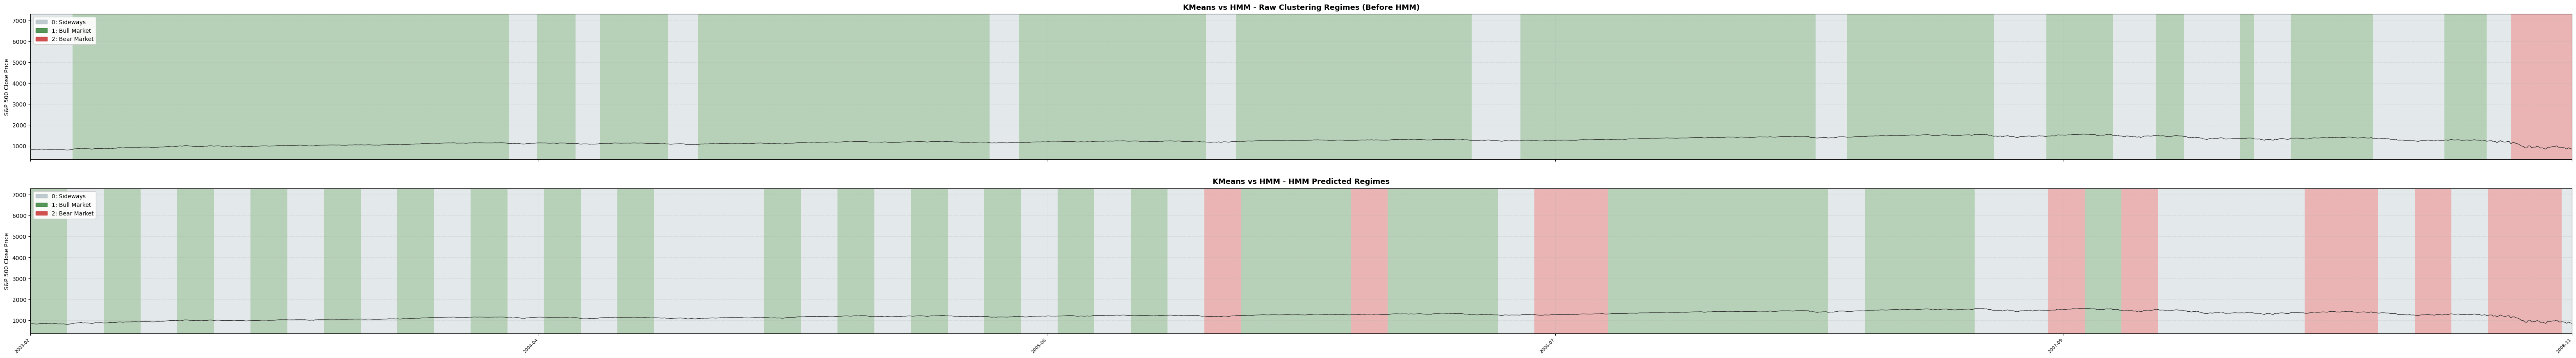

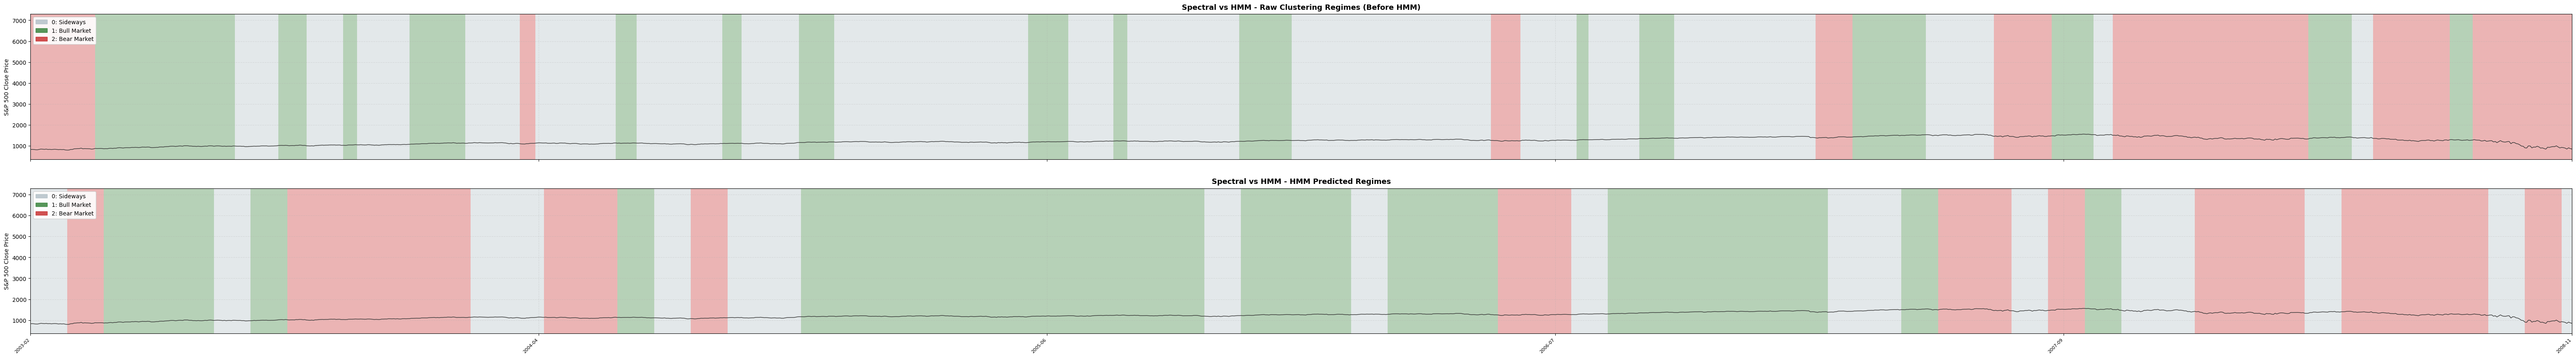

In [14]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def smooth_states(states, min_duration=5):
    """把持续时间短于 min_duration 天的孤立状态合并到前一个状态"""
    states = states.copy().astype(float)
    i = 0
    while i < len(states):
        if pd.isna(states[i]):
            i += 1
            continue
        j = i
        while j < len(states) and states[j] == states[i]:
            j += 1
        if j - i < min_duration:
            fill_val = states[i-1] if i > 0 else (states[j] if j < len(states) else states[i])
            states[i:j] = fill_val
        i = j
    return states


def fill_regimes(ax, dates, states, price, color_map, alpha=0.35):
    """用整数索引位置画色块，避免跳空日期产生碎条纹"""
    ax.plot(range(len(dates)), price, color='#333333', linewidth=1, zorder=3)

    i = 0
    while i < len(states):
        if pd.isna(states[i]):
            i += 1
            continue
        j = i
        while j < len(states) and states[j] == states[i]:
            j += 1
        color = color_map.get(int(states[i]), 'white')
        ax.axvspan(i, min(j, len(states) - 1), alpha=alpha, color=color, linewidth=0)
        i = j

    # 每隔约一年打一个刻度
    tick_step = max(len(dates) // 20, 1)
    tick_positions = range(0, len(dates), tick_step)
    ax.set_xticks(list(tick_positions))
    ax.set_xticklabels(
        [dates[k].strftime('%Y-%m') for k in tick_positions],
        rotation=45, ha='right', fontsize=8
    )
    ax.set_xlim(0, len(dates) - 1)


def plot_regime_comparison(df, price_col, raw_col, hmm_col, title_prefix,
                           min_duration=5, default_view=0.25):
    plot_df = df.dropna(subset=[hmm_col]).copy()

    if not isinstance(plot_df.index, pd.DatetimeIndex):
        plot_df['Date'] = pd.to_datetime(plot_df['Date'])
        plot_df = plot_df.set_index('Date')

    color_map = {0: '#B0BEC5', 1: '#2E7D32', 2: '#C62828'}
    dates = plot_df.index
    price = plot_df[price_col].values

    raw_states = smooth_states(plot_df[raw_col].values, min_duration)
    hmm_states = smooth_states(plot_df[hmm_col].values, min_duration)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(80, 10), sharex=True)
    fig.subplots_adjust(hspace=0.2, bottom=0.1)

    fill_regimes(ax1, dates, raw_states, price, color_map)
    ax1.set_title(f'{title_prefix} - Raw Clustering Regimes (Before HMM)',
                  fontsize=13, fontweight='bold', pad=8)
    ax1.set_ylabel('S&P 500 Close Price')
    ax1.grid(True, linestyle='--', alpha=0.3, zorder=0)

    fill_regimes(ax2, dates, hmm_states, price, color_map)
    ax2.set_title(f'{title_prefix} - HMM Predicted Regimes',
                  fontsize=13, fontweight='bold', pad=8)
    ax2.set_ylabel('S&P 500 Close Price')
    ax2.grid(True, linestyle='--', alpha=0.3, zorder=0)

    legend_patches = [
        mpatches.Patch(color='#B0BEC5', alpha=0.8, label='0: Sideways'),
        mpatches.Patch(color='#2E7D32', alpha=0.8, label='1: Bull Market'),
        mpatches.Patch(color='#C62828', alpha=0.8, label='2: Bear Market')
    ]
    ax1.legend(handles=legend_patches, loc='upper left', framealpha=0.9)
    ax2.legend(handles=legend_patches, loc='upper left', framealpha=0.9)

    # 默认只显示前25%时间段，可左右滑动浏览
    ax1.set_xlim(0, int(len(dates) * default_view))

    plt.show()


# 调用
plot_regime_comparison(output_df,
                       price_col='Close',
                       raw_col='KMeans_Label',
                       hmm_col='HMM_States_KMeans',
                       title_prefix='KMeans vs HMM')

plot_regime_comparison(output_df,
                       price_col='Close',
                       raw_col='Spectral_Synced',
                       hmm_col='HMM_States_Spectral',
                       title_prefix='Spectral vs HMM')

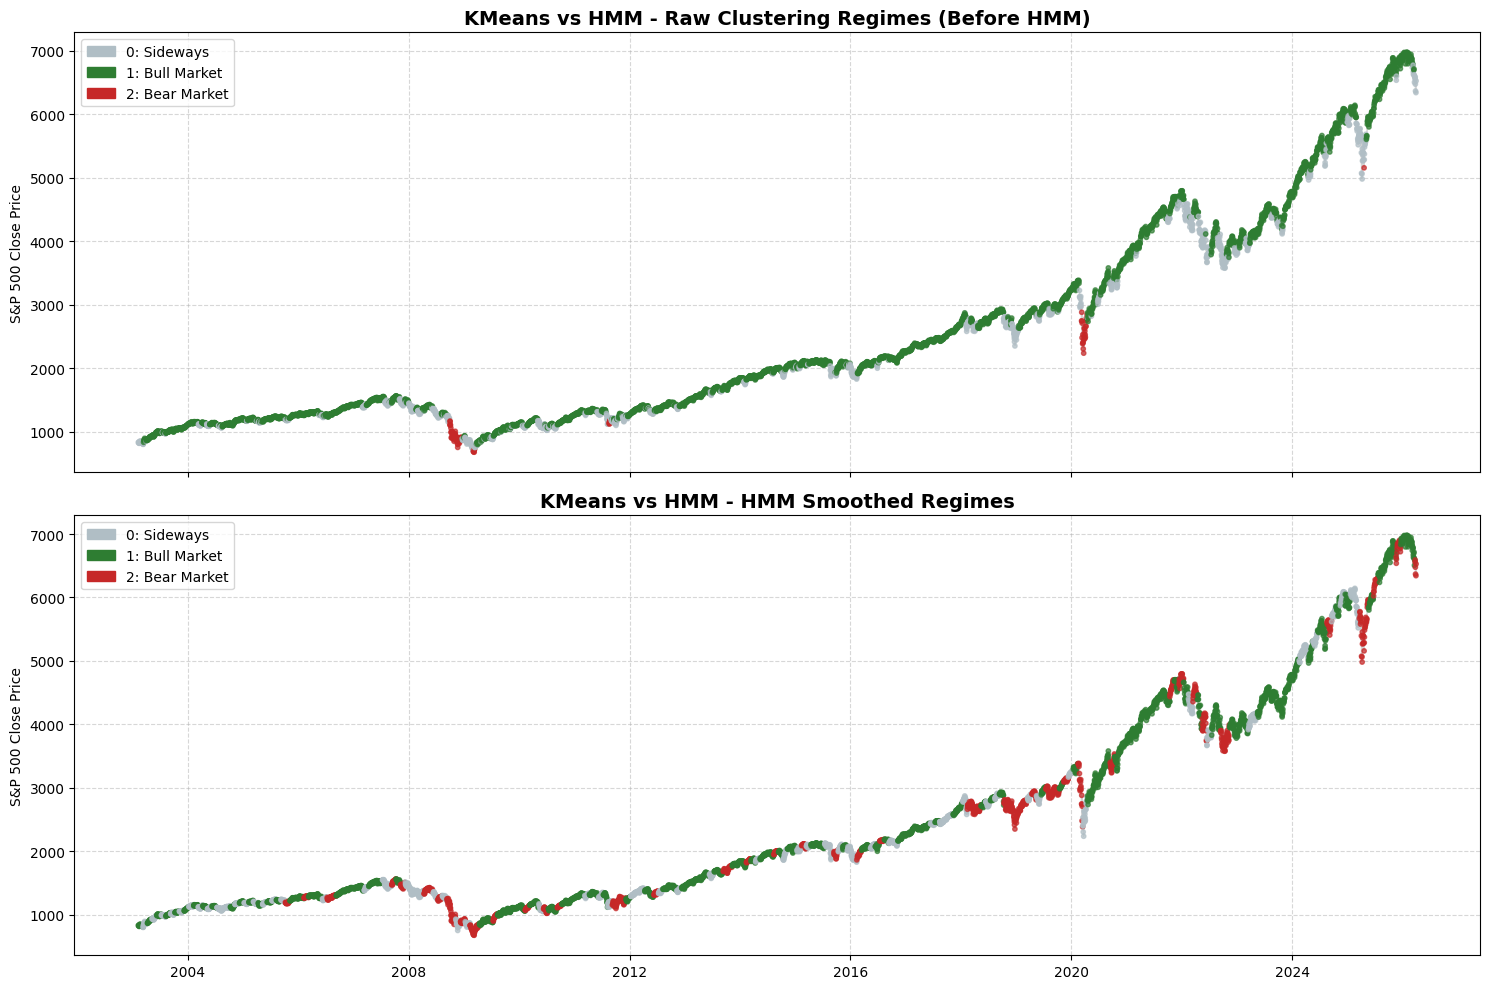

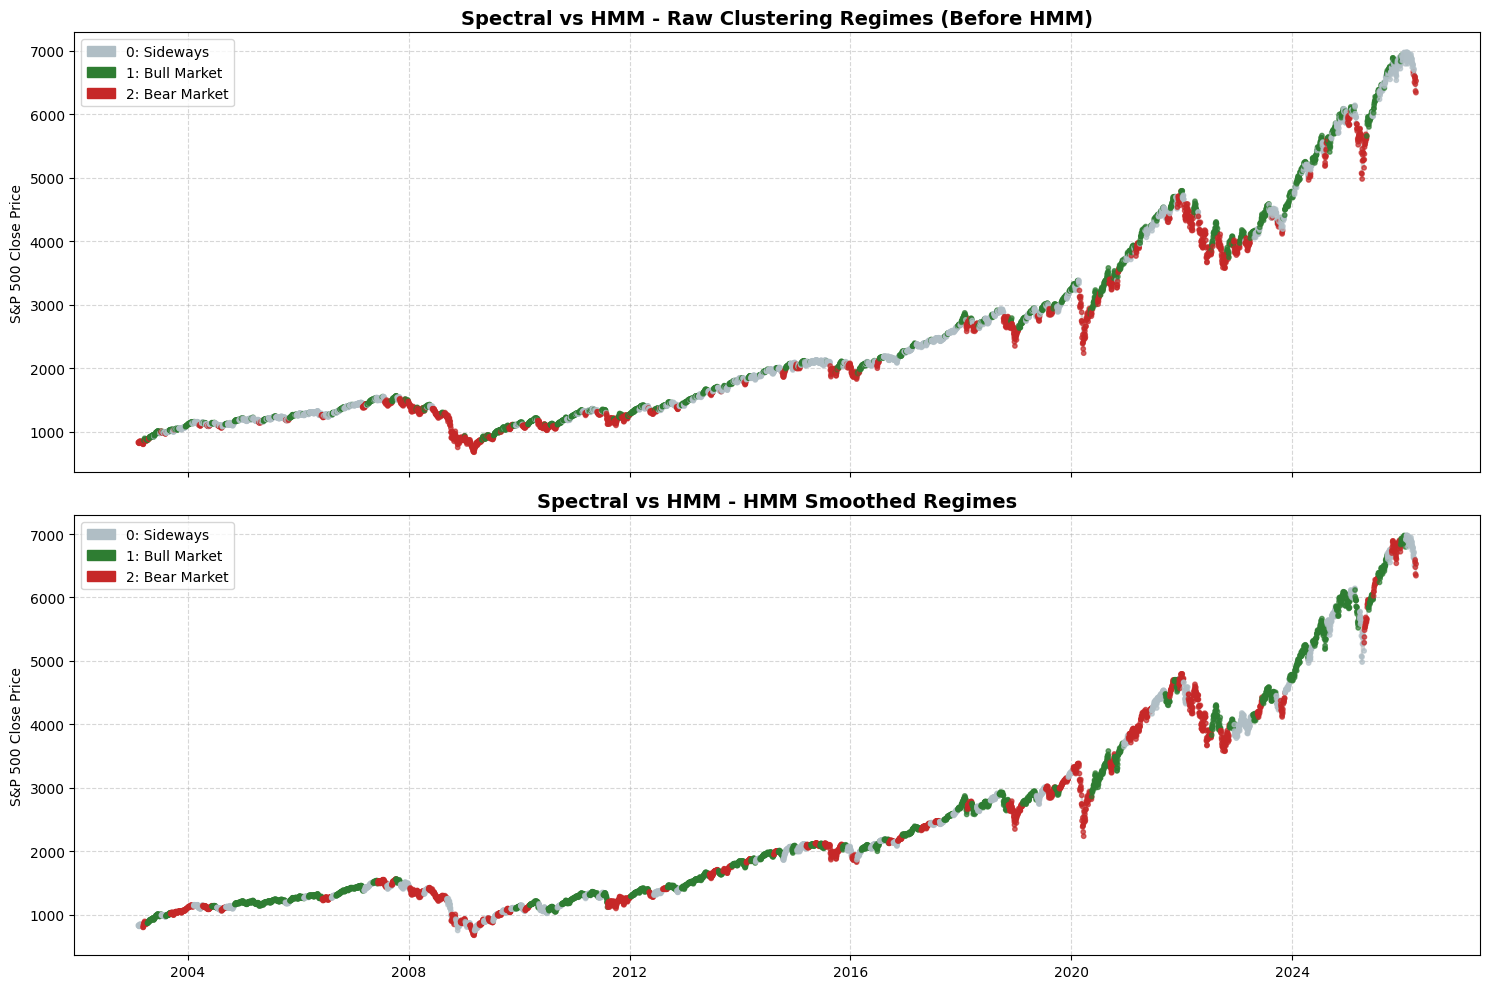

In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def plot_regime_comparison(df, price_col, raw_col, hmm_col, title_prefix):
    """
    绘制原始聚类结果与 HMM 平滑结果的对比图
    """
    # 剔除含有 NaN 的行（主要是前5年没有HMM预测的窗口）
    plot_df = df.dropna(subset=[hmm_col]).copy()
    
    # 确保索引是日期格式，方便画图
    if not isinstance(plot_df.index, pd.DatetimeIndex):
        plot_df['Date'] = pd.to_datetime(plot_df['Date'])
        plot_df = plot_df.set_index('Date')
        
    # 定义统一的颜色映射：0=震荡(灰色), 1=牛市(绿色), 2=熊市(红色)
    color_map = {0: '#B0BEC5', 1: '#2E7D32', 2: '#C62828'}
    
    # 获取颜色列表
    colors_raw = plot_df[raw_col].map(color_map).fillna('black')
    colors_hmm = plot_df[hmm_col].map(color_map).fillna('black')
    
    # 创建上下两个子图
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
    
    # --- 上图：原始聚类结果 ---
    # 画一条浅色的价格底线，把带颜色的散点盖在上面
    ax1.plot(plot_df.index, plot_df[price_col], color='lightgray', linewidth=1, zorder=1)
    ax1.scatter(plot_df.index, plot_df[price_col], c=colors_raw, s=10, zorder=2, alpha=0.7)
    ax1.set_title(f'{title_prefix} - Raw Clustering Regimes (Before HMM)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('S&P 500 Close Price')
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # --- 下图：HMM 平滑后的结果 ---
    ax2.plot(plot_df.index, plot_df[price_col], color='lightgray', linewidth=1, zorder=1)
    ax2.scatter(plot_df.index, plot_df[price_col], c=colors_hmm, s=10, zorder=2, alpha=0.7)
    ax2.set_title(f'{title_prefix} - HMM Smoothed Regimes', fontsize=14, fontweight='bold')
    ax2.set_ylabel('S&P 500 Close Price')
    ax2.grid(True, linestyle='--', alpha=0.5)
    
    # --- 添加图例 ---
    legend_patches = [
        mpatches.Patch(color='#B0BEC5', label='0: Sideways'),
        mpatches.Patch(color='#2E7D32', label='1: Bull Market'),
        mpatches.Patch(color='#C62828', label='2: Bear Market')
    ]
    ax1.legend(handles=legend_patches, loc='upper left')
    ax2.legend(handles=legend_patches, loc='upper left')
    
    plt.tight_layout()
    plt.show()

# ==========================================
# 执行画图
# ==========================================

# 根据你截图的列名，你可能需要微调这里的列名参数：
# 假设你的收盘价叫 'Close'
# KMeans 原始标签由于你在 Notebook 里全量跑出来的叫 'KMeans_Label' (或者截图里的 'KMeans_La')
# HMM 结果叫 'HMM_State' 和 'HMM_States_Spectral'

# 1. 画 KMeans 的对比图
# 请把 'KMeans_La' 替换为你数据里实际代表原始 KMeans 标签的列名
plot_regime_comparison(output_df, 
                       price_col='Close', 
                       raw_col='KMeans_Label',  
                       hmm_col='HMM_States_KMeans', 
                       title_prefix='KMeans vs HMM')

# 2. 画 Spectral 的对比图
# 请把 'Spectral_Sy' 替换为你数据里实际代表原始对齐后谱聚类标签的列名
plot_regime_comparison(output_df, 
                       price_col='Close', 
                       raw_col='Spectral_Synced', 
                       hmm_col='HMM_States_Spectral', 
                       title_prefix='Spectral vs HMM')

In [16]:
# 统计 HMM 预测结果的各状态特征（对应图片里的格式）
import pandas as pd

label_map = {0: 'Sideways', 1: 'Bull Market', 2: 'Bear Market'}

def regime_stats_table(df, state_col, track_name):
    """
    计算各市场状态的平均日收益率、年化收益率、平均波动率、天数、占比
    """
    temp = df.dropna(subset=[state_col]).copy()
    temp['Regime'] = temp[state_col].map(label_map)

    # 用 Log_Return 计算每日收益率统计
    stats = temp.groupby('Regime').agg(
        Avg_Daily_Return  = ('Log_Return',            'mean'),
        Avg_Volatility_21d = ('Rolling_Volatility_21', 'mean'),
        Days              = ('Log_Return',             'count')
    ).reset_index()

    # 年化收益率 = 日均收益率 × 252
    stats['Annualized_Return'] = stats['Avg_Daily_Return'] * 252

    # 占比
    stats['Pct_of_Time'] = stats['Days'] / stats['Days'].sum()

    # 格式化
    stats['Avg_Daily_Return']   = (stats['Avg_Daily_Return']   * 100).map('{:.4f}%'.format)
    stats['Annualized_Return']  = (stats['Annualized_Return']  * 100).map('{:.2f}%'.format)
    stats['Avg_Volatility_21d'] = stats['Avg_Volatility_21d'].map('{:.4f}'.format)
    stats['Pct_of_Time']        = (stats['Pct_of_Time']        * 100).map('{:.1f}%'.format)

    # 排序：Sideways / Bull / Bear
    order = ['Sideways', 'Bull Market', 'Bear Market']
    stats = stats.set_index('Regime').reindex(order).reset_index()

    stats.columns = ['Regime', 'Avg Daily Return', 'Avg Volatility (21d)',
                     'Days', 'Annualized Return', '% of Time']
    stats = stats[['Regime', 'Avg Daily Return', 'Annualized Return',
                   'Avg Volatility (21d)', 'Days', '% of Time']]

    print(f"\n=== {track_name} ===\n")
    print(stats.to_string(index=False))
    print()
    return stats


stats_kmeans   = regime_stats_table(output_df, 'HMM_States_KMeans',   'Track A: KMeans → HMM')
stats_spectral = regime_stats_table(output_df, 'HMM_States_Spectral', 'Track B: Spectral → HMM')


=== Track A: KMeans → HMM ===

     Regime Avg Daily Return Annualized Return Avg Volatility (21d)  Days % of Time
   Sideways          0.0272%             6.85%               0.0106  1533     26.3%
Bull Market          0.0411%            10.36%               0.0079  3108     53.4%
Bear Market          0.0303%             7.63%               0.0137  1182     20.3%


=== Track B: Spectral → HMM ===

     Regime Avg Daily Return Annualized Return Avg Volatility (21d)  Days % of Time
   Sideways          0.0457%            11.53%               0.0104  1491     25.6%
Bull Market          0.0332%             8.36%               0.0073  2499     42.9%
Bear Market          0.0295%             7.44%               0.0127  1833     31.5%

